<a href="https://colab.research.google.com/github/Yashvir10/credit-risk_ml/blob/main/credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import  matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
k=r'/content/new1001.xls'
df= pd.read_excel(k)

In [ ]:
df.info(

)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  30001 non-null  object
 1   X1          30001 non-null  object
 2   X2          30001 non-null  object
 3   X3          30001 non-null  object
 4   X4          30001 non-null  object
 5   X5          30001 non-null  object
 6   X6          30001 non-null  object
 7   X7          30001 non-null  object
 8   X8          30001 non-null  object
 9   X9          30001 non-null  object
 10  X10         30001 non-null  object
 11  X11         30001 non-null  object
 12  X12         30001 non-null  object
 13  X13         30001 non-null  object
 14  X14         30001 non-null  object
 15  X15         30001 non-null  object
 16  X16         30001 non-null  object
 17  X17         30001 non-null  object
 18  X18         30001 non-null  object
 19  X19         30001 non-null  object
 20  X20   

In [ ]:
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [ ]:
df.shape


(30001, 25)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
X9,0


In [ ]:
df.describe()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
count,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001,...,30001,30001,30001,30001,30001,30001,30001,30001,30001,30001
unique,30001,82,3,8,5,57,12,12,12,12,...,21549,21011,20605,7944,7900,7519,6938,6898,6940,3
top,30000,50000,2,2,2,29,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
freq,1,3365,18112,14030,15964,1605,14737,15730,15764,16455,...,3195,3506,4020,5249,5396,5968,6408,6703,7173,23364


In [ ]:
df=df.rename(columns=df.iloc[0])
df=df.drop(0)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 1 to 30000
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          30000 non-null  object
 1   LIMIT_BAL                   30000 non-null  object
 2   SEX                         30000 non-null  object
 3   EDUCATION                   30000 non-null  object
 4   MARRIAGE                    30000 non-null  object
 5   AGE                         30000 non-null  object
 6   PAY_0                       30000 non-null  object
 7   PAY_2                       30000 non-null  object
 8   PAY_3                       30000 non-null  object
 9   PAY_4                       30000 non-null  object
 10  PAY_5                       30000 non-null  object
 11  PAY_6                       30000 non-null  object
 12  BILL_AMT1                   30000 non-null  object
 13  BILL_AMT2                   30000 non-null  ob

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dropna()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29996,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29997,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29998,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29999,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [ ]:
df=df.drop(columns=["ID"])

In [ ]:
df= df.apply(pd.to_numeric,errors='coerce')

<Axes: xlabel='default payment next month', ylabel='count'>

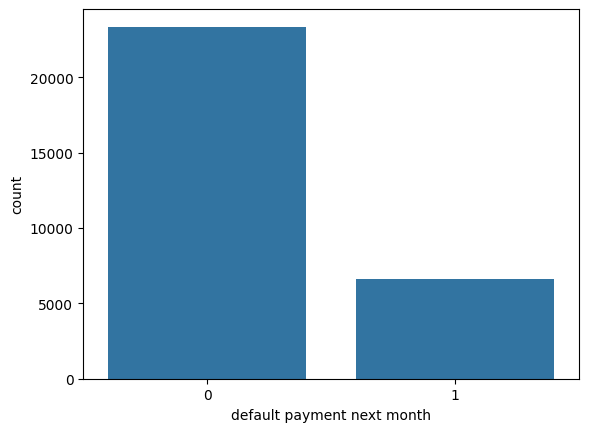

In [ ]:
sns.countplot(x='default payment next month',data=df)

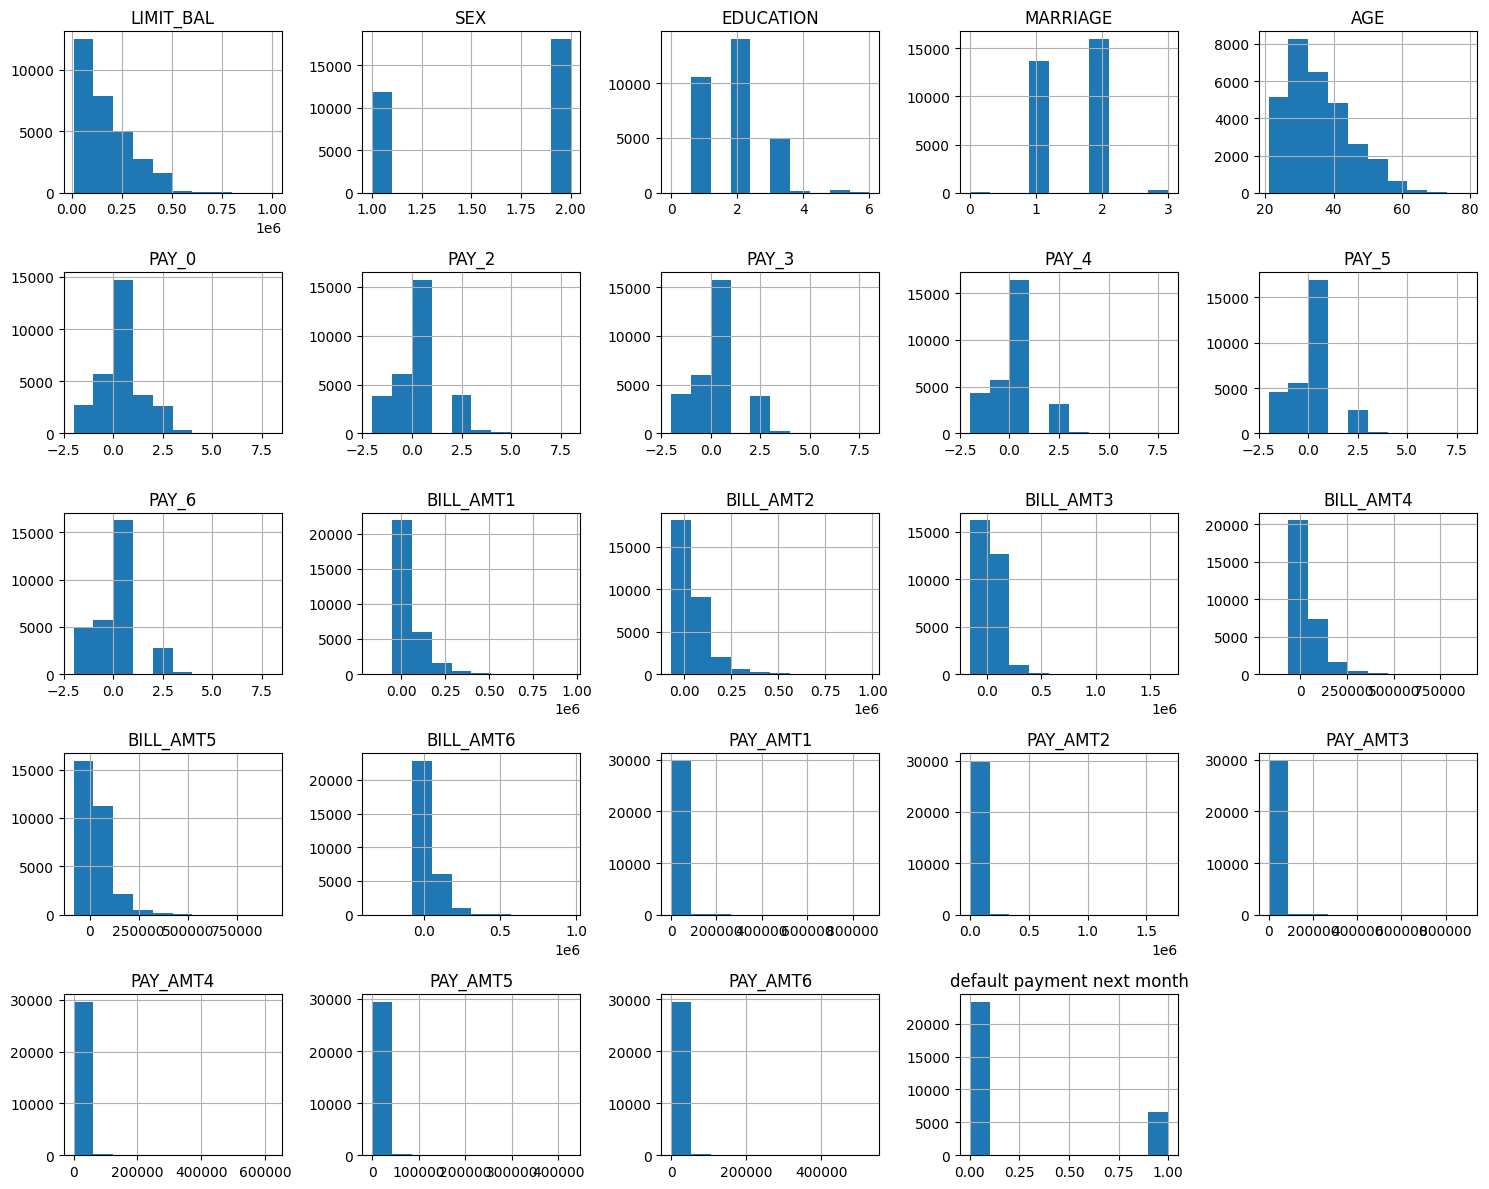

In [ ]:
df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

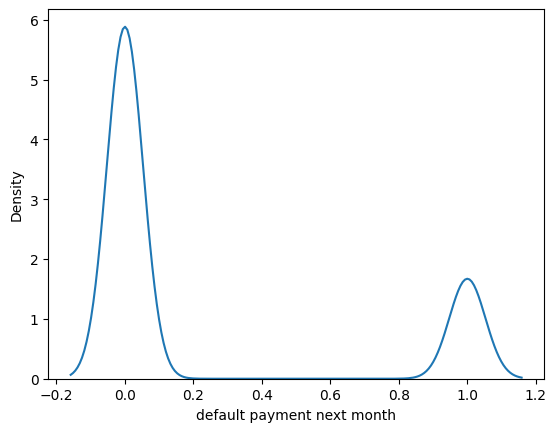

In [ ]:
sns.kdeplot(data=df['default payment next month'])
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score,recall_score,precision_score


In [ ]:
X=df.drop(['default payment next month'],axis=1)
y=df['default payment next month']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)


In [ ]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_sm,y_train_sm=smote.fit_resample(X_train,y_train)
print("early SMOTE:\n",y_train.value_counts())
print("late SMOTE:\n",y_train_sm.value_counts())

early SMOTE:
 default payment next month
0    18691
1     5309
Name: count, dtype: int64
late SMOTE:
 default payment next month
0    18691
1    18691
Name: count, dtype: int64


In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [ ]:
models={
    "logistic regression":LogisticRegression(
        max_iter=1000,
        solver="liblinear", penalty="l2"
    ),
    "knn":KNeighborsClassifier(n_neighbors=7),
    "RandomForest":RandomForestClassifier(n_estimators=1000),
    'decision tree': DecisionTreeClassifier(),
    "naive bayes":GaussianNB(),
    "GradientBoosting":GradientBoostingClassifier(),
     "SVC":SVC(kernel="rbf")

}

In [ ]:
results={}
for name, model in  models.items():
  print(f"\nMODEL{name}...")

  model.fit(X_train_scaled,y_train)
  y_pred=model.predict(X_test_scaled)

  accuracy=accuracy_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred)
  recall =recall_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred)
  if hasattr(model,"predict_proba"):
      y_prob=model.predict_proba(X_test_scaled)[:,1]
  else:
    y_prob=model.decision_function(X_test_scaled)
  roc_auc=roc_auc_score(y_test,y_prob)
  print(f"{name}ROC-AUC Score:{roc_auc:.4f}")
  print(f"{name} Accuracy:{accuracy:.4f}")
  print(f"{name} F1-score:{f1:.4f}")
  print(f"{name} recall:{recall:.4f}")
  print(f"{name}precision:{precision:.4f}")
  print(f"{name} classification report :\n{classification_report(y_test,y_pred)}")
  print(f"{name} Confusion Matrix:\n{confusion_matrix(y_test,y_pred)}")
  results[name]={
      'accuracy':accuracy,
      'f1_score':f1,
      'recall':recall,
      "precision":precision,
      "roc_auc":roc_auc,
      'classification_report': classification_report(y_test,y_pred,output_dict=True),
      'confusion_matrix': confusion_matrix(y_test,y_pred).tolist()
  }


MODELlogistic regression...
logistic regressionROC-AUC Score:0.7076
logistic regression Accuracy:0.8078
logistic regression F1-score:0.3555
logistic regression recall:0.2396
logistic regressionprecision:0.6883
logistic regression classification report :
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

logistic regression Confusion Matrix:
[[4529  144]
 [1009  318]]

MODELknn...
knnROC-AUC Score:0.7100
knn Accuracy:0.8003
knn F1-score:0.4333
knn recall:0.3451
knnprecision:0.5820
knn classification report :
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      4673
           1       0.58      0.35      0.43      1327

    accuracy                           0.80   

In [ ]:
model_results=pd.DataFrame(results)
model_results

,logistic regression,knn,RandomForest,decision tree,naive bayes,GradientBoosting,SVC
accuracy,0.807833,0.800333,0.814333,0.721833,0.7525,0.818333,0.816
f1_score,0.355506,0.433302,0.466986,0.393312,0.497462,0.468811,0.448551
recall,0.239638,0.345139,0.367747,0.407687,0.553881,0.362472,0.338357
precision,0.688312,0.581957,0.639581,0.379916,0.451474,0.663448,0.665185
roc_auc,0.707573,0.709969,0.757989,0.609714,0.72493,0.778394,0.721039
classification_report,"{'0': {'precision': 0.8178042614662333, 'recal...","{'0': {'precision': 0.8333013619796662, 'recal...","{'0': {'precision': 0.8397937750620584, 'recal...","{'0': {'precision': 0.8282342657342657, 'recal...","{'0': {'precision': 0.8645928636779506, 'recal...","{'0': {'precision': 0.8396208530805688, 'recal...","{'0': {'precision': 0.8351173708920188, 'recal..."
confusion_matrix,"[[4529, 144], [1009, 318]]","[[4344, 329], [869, 458]]","[[4398, 275], [839, 488]]","[[3790, 883], [786, 541]]","[[3780, 893], [592, 735]]","[[4429, 244], [846, 481]]","[[4447, 226], [878, 449]]"


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
rf_params={
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}
rf_grid=GridSearchCV(RandomForestClassifier(),rf_params,cv=3)
rf_grid.fit(X_train_scaled,y_train)
print("Best RF Params:",rf_grid.best_params_)

Best RF Params: {'max_depth': 10, 'n_estimators': 100}


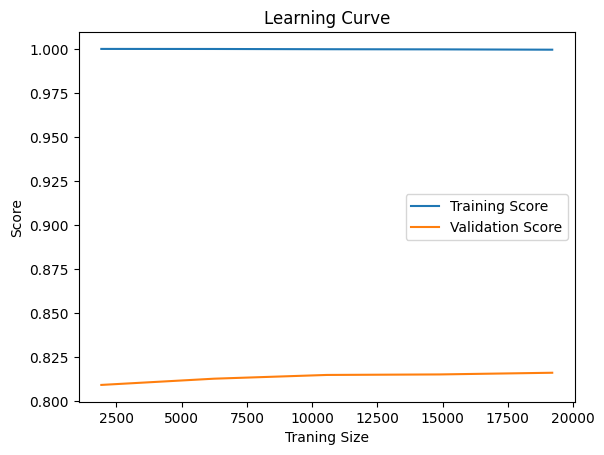

In [ ]:
from sklearn.model_selection import learning_curve
train_sizes , train_scores ,test_scores = learning_curve(
    RandomForestClassifier(),
    X_train_scaled,
    y_train,
    cv=5
    )
train_mean=train_scores.mean(axis=1)
test_mean=test_scores.mean (axis=1)
plt.plot(train_sizes,train_mean,label="Training Score")
plt.plot(train_sizes,test_mean,label="Validation Score")
plt.legend()
plt.xlabel("Traning Size")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.show()
